# Регрессия SI

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     cross_val_score,)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (mean_squared_error, r2_score,
                             mean_absolute_error, make_scorer)

In [ ]:
df = pd.read_csv('/content/df.csv')

In [ ]:
df.head()

,IC50,CC50,SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,IC50_log,CC50_log,SI_log
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


In [ ]:
df.shape

(969, 158)

### Проверим целесообразность использования _log версии таргета

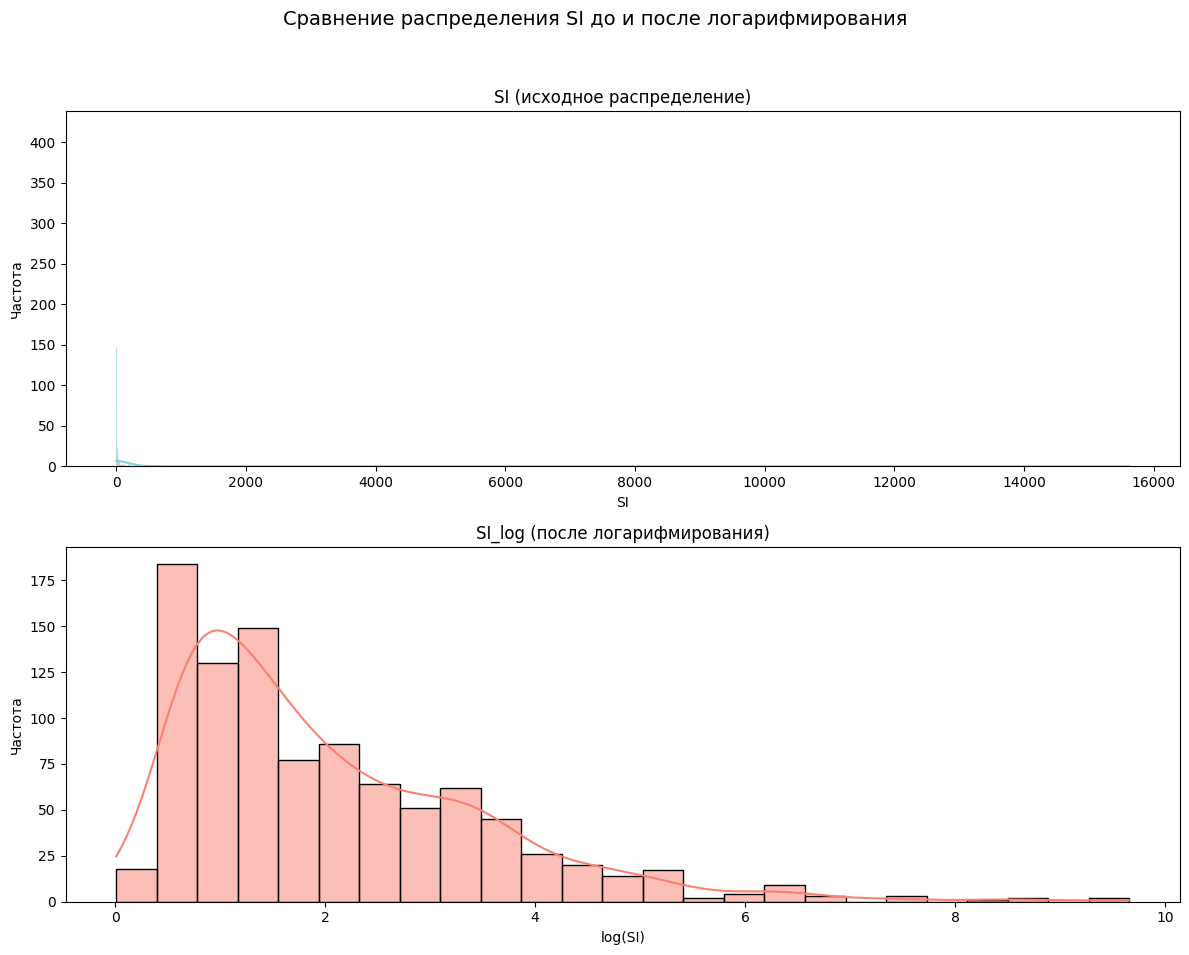

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# SI
sns.histplot(
    df['SI'],
    kde=True,
    ax=axes[0],
    color='skyblue'
)
axes[0].set_title('SI (исходное распределение)')
axes[0].set_xlabel('SI')
axes[0].set_ylabel('Частота')

# SI_log
sns.histplot(
    df['SI_log'],
    kde=True,
    ax=axes[1],
    color='salmon')

axes[1].set_title('SI_log (после логарифмирования)')
axes[1].set_xlabel('log(SI)')
axes[1].set_ylabel('Частота')

plt.suptitle('Сравнение распределения SI до и после логарифмирования', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

SI_log демонстрирует лучшее распределение, так что используем его

,Model,RMSE,MAE,R²
0,RandomForest,1.318575,0.948625,0.230492
1,LinearRegression,1.385230,1.073110,0.150726
2,XGBoost,1.401778,1.019897,0.130315


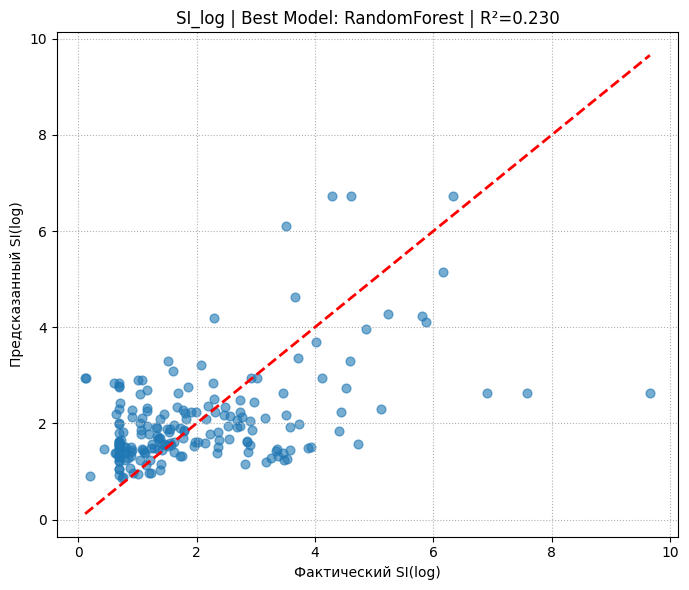

In [ ]:
y = df['SI_log']
X = df.drop(columns=['IC50', 'CC50', 'SI',
                     'IC50_log', 'CC50_log', 'SI_log'],
            errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.9)),
        ('model', LinearRegression())]),

    'RandomForest': RandomForestRegressor(
        random_state=42,
        n_jobs=-1),

    'XGBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1)}

param_random = {
    'RandomForest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [10, 20],
        'min_samples_split': [2, 4, 8],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 0.5, 0.8],
        'bootstrap': [True, False],},

    'XGBoost': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]}}

results = []
best_models = {}

for model_name, model in models.items():

    search = (
        RandomizedSearchCV(
            model,
            param_distributions=param_random[model_name],
            n_iter=10,
            cv=3,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            random_state=42)
        if model_name in param_random
        else None)

    if search is not None:
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
    else:
        best_model = model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)

    results.append({
        'Model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)})

    best_models[model_name] = {
        'model': best_model,
        'X_test': X_test,
        'y_test': y_test}

results_df = (
    pd.DataFrame(results)
    .sort_values('R²', ascending=False)
    .reset_index(drop=True))

display(results_df)

# +визуализация
best_row = results_df.iloc[0]
best_name = best_row['Model']

model_info = best_models[best_name]

y_pred = model_info['model'].predict(model_info['X_test'])
y_test = model_info['y_test']

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())]

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6, s=40)
plt.plot(lims, lims, 'r--', linewidth=2)

plt.title(f'SI_log | Best Model: {best_name} | R²={best_row["R²"]:.3f}')
plt.xlabel('Фактический SI(log)')
plt.ylabel('Предсказанный SI(log)')
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

## Интерпретация результатов моделей
- SI после логарифмирования (SI_log) имеет более стабильное распределение, немного улучшая качество модели
- Лучший результат даёт RandomForest (R² ≈ 0.23), при этом остальные модели показывают ещё более низкие значения
- Слабое качество объясняется природой SI как производной метрики (CC50/IC50), а также сильным искажением распределения

# Вывод:
SI плохо предсказывается по имеющимся признакам. Использовать его в виде непрерывной целевой переменной нецелесообразно, но он может быть вспомогательным индикатором

